# Look at one real HEST-1k sample (no `hest` package needed)

This skips installing the `hest` library entirely — that install was the thing stalling
out. Everything here only needs `huggingface_hub`, `pandas`, `anndata`, `h5py`, `PIL`, and
`matplotlib`, which install in seconds.

**Before running:** make sure you've accepted access on
https://huggingface.co/datasets/MahmoodLab/hest and have a fresh **Read-only** token from
https://huggingface.co/settings/tokens (paste it only into the `login()` prompt below, never
into a chat).

In [ ]:
!pip install -q huggingface_hub pandas anndata h5py pillow matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


## 1. Log in to Hugging Face

In [ ]:
from huggingface_hub import login
login()  # paste your token when prompted

## 2. Pull the metadata table and pick a sample id

In [ ]:
from huggingface_hub import hf_hub_download
import pandas as pd

meta_path = hf_hub_download(
    repo_id="MahmoodLab/hest",
    repo_type="dataset",
    filename="HEST_v1_1_0.csv",
)
meta = pd.read_csv(meta_path)
meta[['id', 'organ', 'species', 'st_technology', 'oncotree_code']].head(20)

HEST_v1_1_0.csv:   0%|          | 0.00/535k [00:00<?, ?B/s]

,id,organ,species,st_technology,oncotree_code
0,TENX159,Brain,Mus musculus,Xenium,NaN
1,TENX158,Skin,Homo sapiens,Xenium,SKCM
2,TENX157,Prostate,Homo sapiens,Xenium,PRAD
3,TENX156,Bowel,Homo sapiens,Visium HD,COAD
4,TENX155,Bowel,Homo sapiens,Visium HD,COAD
5,TENX154,Bowel,Homo sapiens,Visium HD,COAD
6,TENX153,Bowel,Homo sapiens,Visium HD,NaN
7,TENX152,Bowel,Homo sapiens,Visium,COAD
8,TENX149,Bowel,Homo sapiens,Xenium,COAD
9,TENX148,Bowel,Homo sapiens,Xenium,COAD


In [ ]:
# Adjust this filter to match your project's cohort
meta[meta['organ'].str.contains('Breast', case=False, na=False)][['id', 'organ', 'species', 'st_technology']]

,id,organ,species,st_technology
153,TENX99,Breast,Homo sapiens,Xenium
154,TENX98,Breast,Homo sapiens,Xenium
155,TENX97,Breast,Homo sapiens,Xenium
156,TENX96,Breast,Homo sapiens,Xenium
157,TENX95,Breast,Homo sapiens,Xenium
...,...,...,...,...
373,SPA0,Breast,Homo sapiens,Spatial Transcriptomics
565,NCBI785,Breast,Homo sapiens,Xenium
566,NCBI784,Breast,Homo sapiens,Xenium
567,NCBI783,Breast,Homo sapiens,Xenium


## 3. Download a few small files for ONE sample\n\nThis deliberately skips `wsis/` (the multi-GB whole-slide TIFFs) and only pulls small per-sample files, so it should finish in well under a minute.

In [ ]:
import glob
from huggingface_hub import snapshot_download

sample_id = "TENX95"  # <-- swap in an id from the table above

snapshot_download(
    repo_id="MahmoodLab/hest",
    repo_type="dataset",
    local_dir="hest_data",
    allow_patterns=[
        f"spatial_plots/*{sample_id}*",
        f"thumbnails/*{sample_id}*",
        f"st/*{sample_id}*",
        f"patches/*{sample_id}*",
    ],
)
print(glob.glob(f"hest_data/**/*{sample_id}*", recursive=True))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

['hest_data/spatial_plots/TENX95_spatial_plots.png', 'hest_data/thumbnails/TENX95_downscaled_fullres.jpeg', 'hest_data/st/TENX95.h5ad', 'hest_data/patches/TENX95.h5']


## 4. Immediate payoff — the dataset's own premade overlay\n\nHEST-1k ships a ready-made picture of the tissue with capture spots overlaid, per sample.

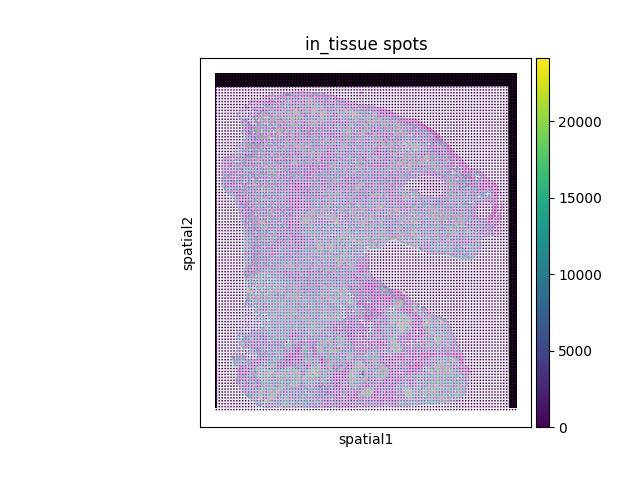

In [ ]:
from PIL import Image

img_path = glob.glob(f"hest_data/spatial_plots/*{sample_id}*")[0]
Image.open(img_path)

## 5. One real patch next to its real expression\n\nRun the next cell first and check what it prints — that confirms the actual dataset names inside the patches file before we index into it.

In [ ]:
import h5py

patches_path = glob.glob(f"hest_data/patches/*{sample_id}*")[0]
with h5py.File(patches_path, "r") as f:
    print(list(f.keys()))

['barcode', 'coords', 'img']


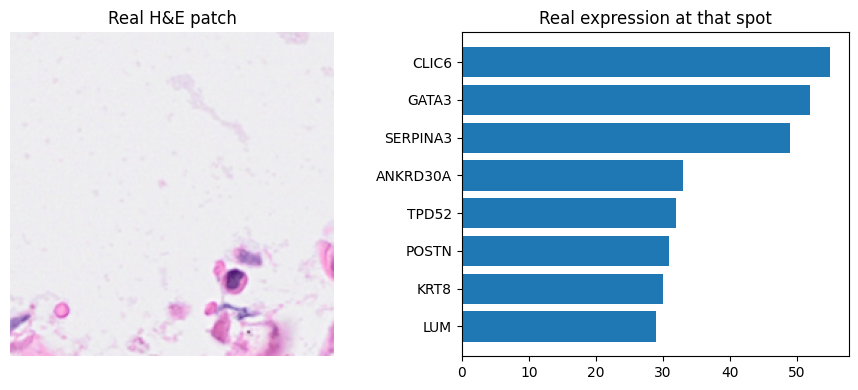

In [ ]:
import anndata
import numpy as np
import matplotlib.pyplot as plt

adata = anndata.read_h5ad(glob.glob(f"hest_data/st/*{sample_id}*")[0])

with h5py.File(patches_path, "r") as f:
    imgs = f["img"][:]
    raw_barcodes = f["barcode"][:]
    barcodes = []
    for b in raw_barcodes:
        if hasattr(b, "ravel"):
            b = b.ravel()[0]
        if isinstance(b, bytes):
            b = b.decode()
        barcodes.append(b)

i = 0
patch = imgs[i]
row = adata[adata.obs_names == barcodes[i]] if barcodes[i] in adata.obs_names else adata[i]

expr = row.X.toarray().ravel() if hasattr(row.X, "toarray") else np.asarray(row.X).ravel()
top = np.argsort(expr)[-8:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(patch)
axes[0].axis("off")
axes[0].set_title("Real H&E patch")
axes[1].barh(row.var_names[top][::-1], expr[top][::-1])
axes[1].set_title("Real expression at that spot")
plt.tight_layout()
plt.show()

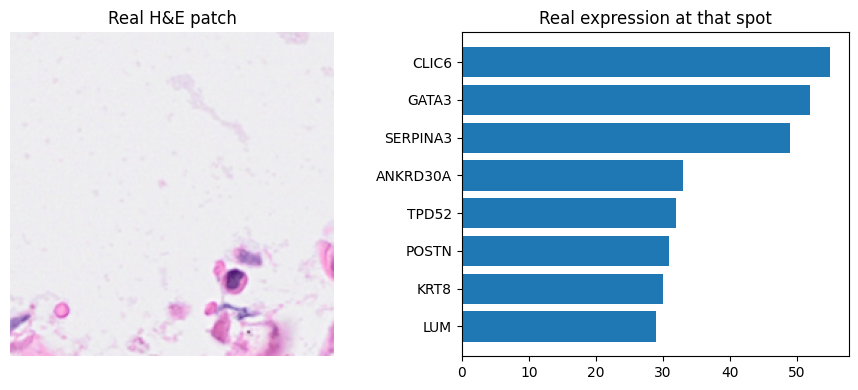

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import glob, shutil
import h5py, anndata, numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Copy the premade spatial overlay to a clean filename
overview_src = glob.glob(f"hest_data/spatial_plots/*{sample_id}*")[0]
shutil.copy(overview_src, "spatial_overview.png")

# 2. Rebuild the patch + expression chart at high resolution
adata = anndata.read_h5ad(glob.glob(f"hest_data/st/*{sample_id}*")[0])
patches_path = glob.glob(f"hest_data/patches/*{sample_id}*")[0]

with h5py.File(patches_path, "r") as f:
    imgs = f["img"][:]
    raw_barcodes = f["barcode"][:]
    barcodes = []
    for b in raw_barcodes:
        if hasattr(b, "ravel"):
            b = b.ravel()[0]
        if isinstance(b, bytes):
            b = b.decode()
        barcodes.append(b)

i = 0
patch = imgs[i]
row = adata[adata.obs_names == barcodes[i]] if barcodes[i] in adata.obs_names else adata[i]
expr = row.X.toarray().ravel() if hasattr(row.X, "toarray") else np.asarray(row.X).ravel()
top = np.argsort(expr)[-8:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(patch); axes[0].axis("off"); axes[0].set_title("Real H&E patch")
axes[1].barh(row.var_names[top][::-1], expr[top][::-1]); axes[1].set_title("Real expression at that spot")
plt.tight_layout()
plt.savefig("patch_expr.png", dpi=200, bbox_inches="tight")
plt.show()

# 3. Download both files to your computer
files.download("spatial_overview.png")
files.download("patch_expr.png")

---
If step 5's key names don't match `"img"` / `"barcode"`, that's the only thing likely to
need changing — everything else here works off files you've already downloaded.